# OnHW-Words500 character distribution

Compare the **public right-handed OnHW-Words500** annotations used by our TVA experiments with Figure 3 in [Tokenization vs. Augmentation](https://arxiv.org/html/2603.16883v1#A1).

The paper displays **the first fold**, WD above WI, with blue training bars and orange validation bars. This notebook reproduces that layout for our processed fold 0 and describes every available fold. It reads labels from `train.json` and `val.json`; no tokenization, case folding, augmentation, or model training is applied.

Similar character frequencies support similar label balance. They do **not** establish identical recordings, writers, sensor quality, preprocessing, or training difficulty. The paper's numerical character counts are unavailable, so no numerical similarity to its plotted bars is claimed.

In [1]:
from collections import Counter
import csv
import hashlib
import html
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

# Select the existing Python (tva-thesis) / TVA kernel, then Run All.
# Override TVA_ONHW_DATA_ROOT if the prepared datasets are stored elsewhere.
REPO_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents]
     if (path / "prepare_dataset.ipynb").is_file()),
    Path.cwd(),
)
DATA_ROOT = Path(os.environ.get(
    "TVA_ONHW_DATA_ROOT", str(REPO_ROOT / "data" / "tva")
)).expanduser()
DATASET_DIRS = {
    "WD": DATA_ROOT / "onhw_words500_wd_word_rh",
    "WI": DATA_ROOT / "onhw_words500_wi_word_rh",
}
FOLD_TO_PLOT = 0
EXPORT = True
OUTPUT_DIR = REPO_ROOT / "results" / "onhw_distribution"
PAPER_URL = "https://arxiv.org/html/2603.16883v1"
print(f"Data root: {DATA_ROOT}")
print(f"Outputs: {OUTPUT_DIR} (EXPORT={EXPORT})")

Data root: /home/artellisys/TVA/data/tva
Outputs: /home/artellisys/TVA/results/onhw_distribution (EXPORT=True)


## Load the annotations used by training

Each occurrence of a character is counted, including repeated letters in a word and repeated recordings of the same word. Each split is normalized by **its own total number of characters**, rather than by its sample count or vocabulary size. Zero-count alphabet entries remain visible. Whitespace or characters outside the declared alphabet cause an explicit error rather than being silently discarded.

The preparation notebook filters empty signals and signals longer than 1,024 frames. These charts therefore describe the **prepared training/evaluation population**, not every recording in the original download. It enumerates raw fold directories without sorting; our processed fold numbers alone do not prove correspondence with the paper's fold numbering.

In [2]:
datasets = {}
source_records = []
for setting, directory in DATASET_DIRS.items():
    datasets[setting] = {}
    for partition in ("train", "val"):
        path = directory / f"{partition}.json"
        payload = path.read_bytes()
        document = json.loads(payload)
        expected_wi = setting == "WI"
        if document["info"]["writer_independent"] != expected_wi:
            raise ValueError(f"Incorrect writer protocol in {path}")
        folds = document["annotations"]
        if not folds or len(folds) != document["info"]["num_fold"]:
            raise ValueError(f"Fold metadata does not match annotations: {path}")
        datasets[setting][partition] = document
        source_records.append({
            "setting": setting, "partition": partition,
            "path": str(path), "sha256": hashlib.sha256(payload).hexdigest(),
            "info": document["info"],
        })
    if set(datasets[setting]["train"]["annotations"]) != set(
        datasets[setting]["val"]["annotations"]
    ):
        raise ValueError(f"Train and validation fold IDs differ: {setting}")

# Python's character sort matches the prepared annotation category order:
# ASCII uppercase, ASCII lowercase, then the German characters.
alphabet_sets = [
    set(document["categories"])
    for splits in datasets.values() for document in splits.values()
]
if any(chars != alphabet_sets[0] for chars in alphabet_sets):
    raise ValueError("The four annotation files declare different alphabets.")
ALPHABET = sorted(alphabet_sets[0])
if "" in ALPHABET or any(char.isspace() or len(char) != 1 for char in ALPHABET):
    raise ValueError("Expected a nonblank, single-character alphabet.")
FOLDS = {
    setting: sorted(map(int, splits["train"]["annotations"]))
    for setting, splits in datasets.items()
}
if any(FOLD_TO_PLOT not in folds for folds in FOLDS.values()):
    raise ValueError(f"Requested fold {FOLD_TO_PLOT} is unavailable.")
print(f"Alphabet ({len(ALPHABET)} characters): {''.join(ALPHABET)}")
print(f"Available folds: {FOLDS}")

Alphabet (59 characters): ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyzÄÖÜßäöü
Available folds: {'WD': [0, 1, 2, 3, 4], 'WI': [0, 1, 2, 3, 4]}


In [3]:
def markdown_table(headers, rows):
    def escaped(value):
        return html.escape(str(value)).replace("|", "&#124;").replace("\n", " ")
    lines = [
        "| " + " | ".join(map(escaped, headers)) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    lines.extend("| " + " | ".join(map(escaped, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


def character_distribution(annotations):
    if not annotations:
        raise ValueError("Cannot analyze an empty fold.")
    if any(not isinstance(anno["label"], str) or not anno["label"]
           for anno in annotations):
        raise ValueError("Labels must be nonempty strings.")
    counts = Counter(char for anno in annotations for char in anno["label"])
    unexpected = set(counts) - set(ALPHABET)
    if unexpected:
        raise ValueError(f"Unexpected characters: {sorted(unexpected)!r}")
    values = np.array([counts[char] for char in ALPHABET], dtype=np.int64)
    frequency = values / values.sum()
    assert int(values.sum()) == sum(len(anno["label"]) for anno in annotations)
    assert np.isclose(frequency.sum(), 1.0)
    return {"counts": values, "frequency": frequency,
            "total_characters": int(values.sum()), "samples": len(annotations)}


def js_divergence_bits(p, q):
    # Jensen-Shannon divergence with base-2 logs: 0 = identical, 1 = disjoint.
    midpoint = (p + q) / 2
    def kl(a):
        mask = a > 0
        return float(np.sum(a[mask] * np.log2(a[mask] / midpoint[mask])))
    return (kl(p) + kl(q)) / 2


distributions = {}
summary_rows = []
character_rows = []
for setting, splits in datasets.items():
    for fold in FOLDS[setting]:
        key = str(fold)
        annotations = {
            partition: splits[partition]["annotations"][key]
            for partition in ("train", "val")
        }
        distributions[setting, fold] = {
            partition: character_distribution(annos)
            for partition, annos in annotations.items()
        }
        train, val = (distributions[setting, fold][partition]
                      for partition in ("train", "val"))
        p, q = train["frequency"], val["frequency"]
        writers = {
            partition: {str(anno["id_writer"]) for anno in annos}
            for partition, annos in annotations.items()
        }
        overlap = writers["train"] & writers["val"]
        if setting == "WI" and overlap:
            raise ValueError(f"Writer leakage in WI fold {fold}: {sorted(overlap)}")
        words = {
            partition: {anno["label"] for anno in annos}
            for partition, annos in annotations.items()
        }
        unseen = words["val"] - words["train"]
        summary_rows.append({
            "setting": setting, "fold": fold,
            "train_samples": train["samples"], "val_samples": val["samples"],
            "train_characters": train["total_characters"],
            "val_characters": val["total_characters"],
            "train_writers": len(writers["train"]),
            "val_writers": len(writers["val"]), "writer_overlap": len(overlap),
            "train_unique_words": len(words["train"]),
            "val_unique_words": len(words["val"]),
            "unseen_val_word_types": len(unseen),
            "unseen_val_samples": sum(anno["label"] in unseen for anno in annotations["val"]),
            "total_variation": float(np.abs(p - q).sum() / 2),
            "js_divergence_bits": js_divergence_bits(p, q),
            "max_gap_pp": float(np.abs(p - q).max() * 100),
            "absent_train": [char for char, count in zip(ALPHABET, train["counts"]) if count == 0],
            "absent_val": [char for char, count in zip(ALPHABET, val["counts"]) if count == 0],
        })
        for index, char in enumerate(ALPHABET):
            character_rows.append({
                "setting": setting, "fold": fold, "character": char,
                "train_count": int(train["counts"][index]),
                "val_count": int(val["counts"][index]),
                "train_frequency": float(p[index]),
                "val_frequency": float(q[index]),
                "val_minus_train_pp": float((q[index] - p[index]) * 100),
            })

markdown_table(
    ["Setting", "Fold", "Train samples", "Val samples", "Train / val writers",
     "Writer overlap", "Train / val unique words", "Unseen val word types"],
    [[r["setting"], r["fold"], r["train_samples"], r["val_samples"],
      f'{r["train_writers"]} / {r["val_writers"]}', r["writer_overlap"],
      f'{r["train_unique_words"]} / {r["val_unique_words"]}',
      r["unseen_val_word_types"]] for r in summary_rows],
)

| Setting | Fold | Train samples | Val samples | Train / val writers | Writer overlap | Train / val unique words | Unseen val word types |
| --- | --- | --- | --- | --- | --- | --- | --- |
| WD | 0 | 20163 | 5036 | 53 / 53 | 53 | 479 / 136 | 22 |
| WD | 1 | 20160 | 5039 | 53 / 53 | 53 | 501 / 202 | 0 |
| WD | 2 | 20160 | 5039 | 53 / 53 | 53 | 465 / 191 | 36 |
| WD | 3 | 20158 | 5041 | 53 / 53 | 53 | 484 / 226 | 17 |
| WD | 4 | 20161 | 5038 | 53 / 53 | 53 | 499 / 225 | 2 |
| WI | 0 | 19907 | 5292 | 42 / 11 | 0 | 501 / 500 | 0 |
| WI | 1 | 20078 | 5121 | 42 / 11 | 0 | 501 / 500 | 0 |
| WI | 2 | 20202 | 4997 | 43 / 10 | 0 | 500 / 501 | 1 |
| WI | 3 | 20520 | 4679 | 43 / 10 | 0 | 501 / 500 | 0 |
| WI | 4 | 20089 | 5110 | 42 / 11 | 0 | 501 / 500 | 0 |

## Figure 3 comparison: WD above WI

Blue = training; orange = validation. Both panels share character order and the same y-axis range. Values are fractions (0.16 means 16% of character occurrences), matching the scale shown in the paper. The title identifies our actual processed fold.

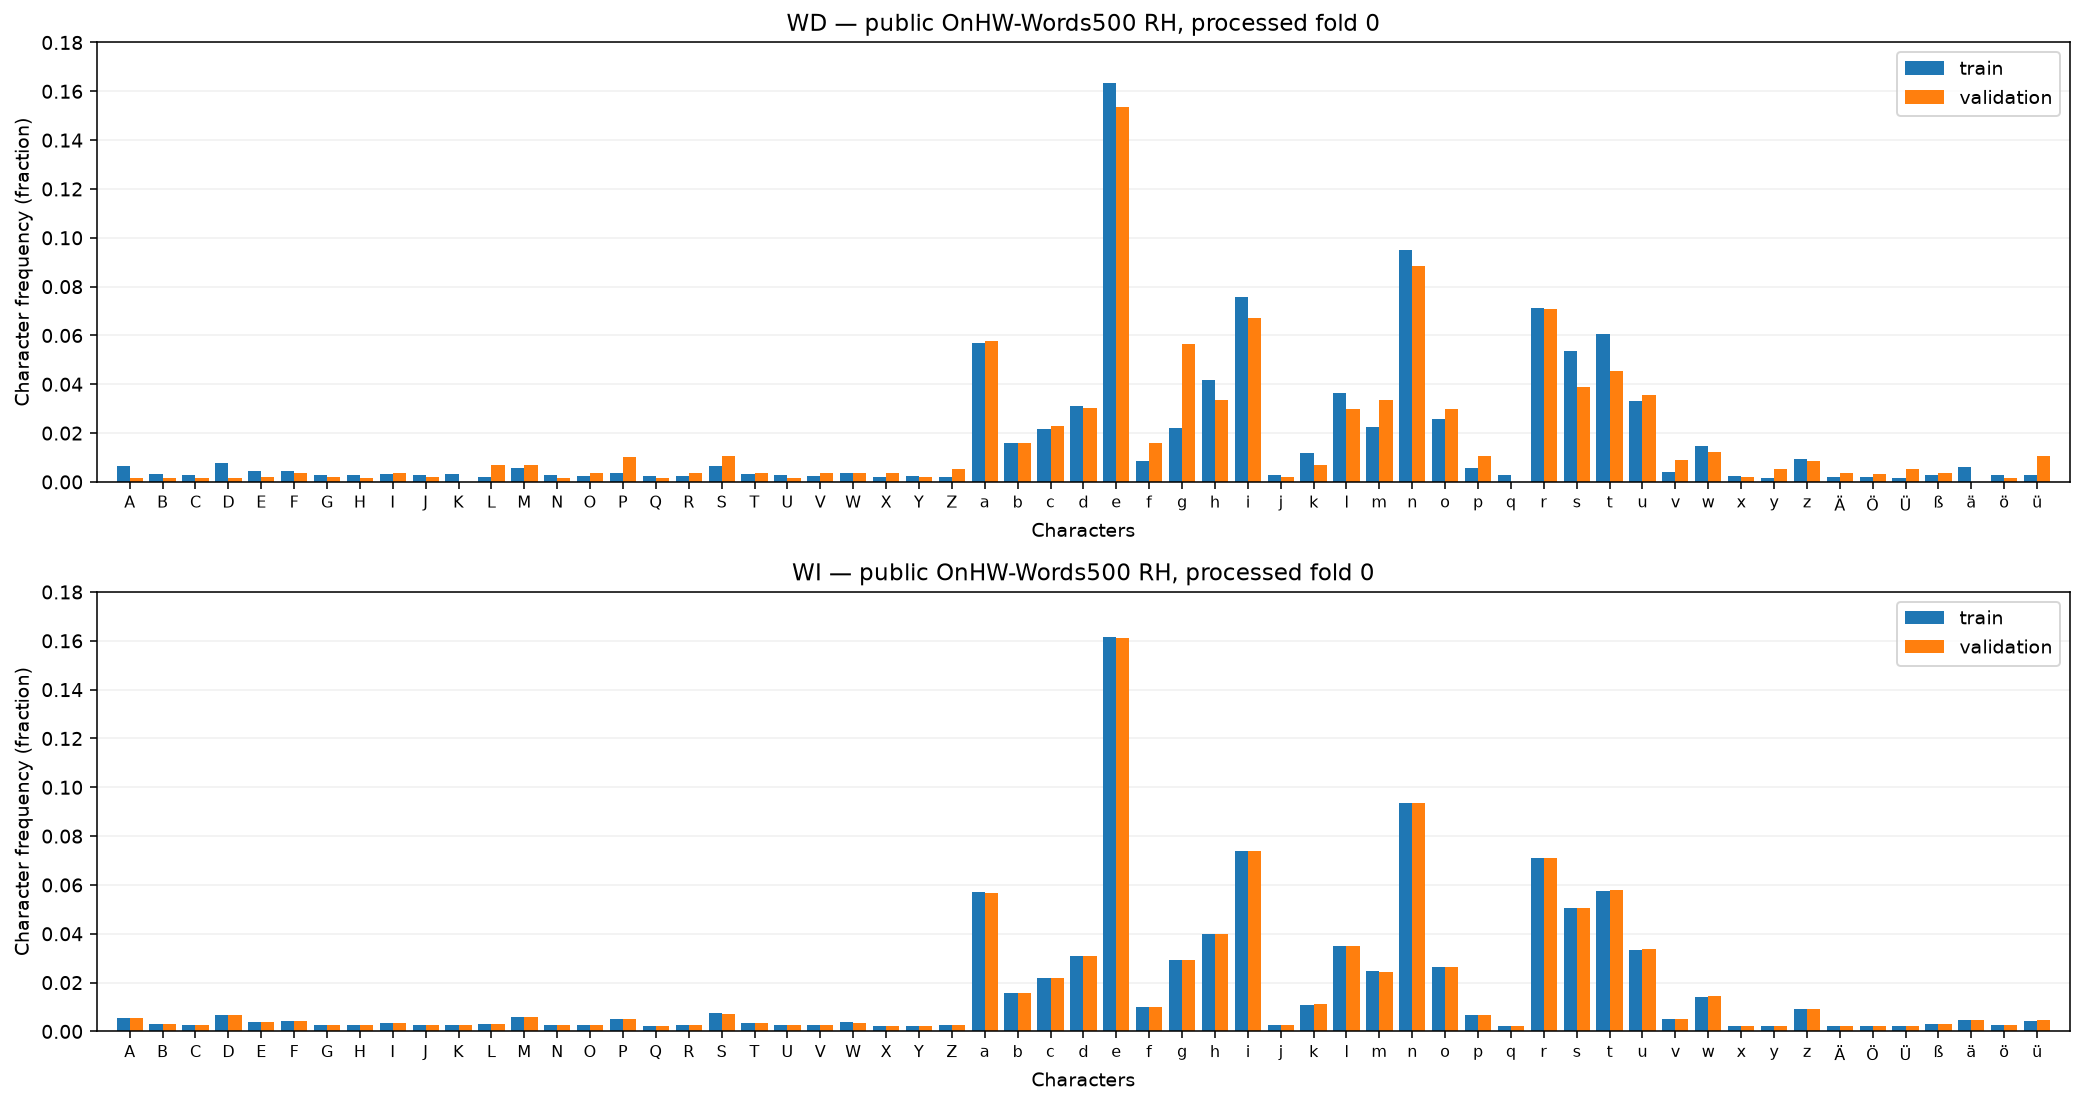

In [4]:
figures = {}

def plot_character_distribution(fold):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True, sharey=True)
    x = np.arange(len(ALPHABET))
    width = 0.40
    peak = max(
        distributions[setting, fold][partition]["frequency"].max()
        for setting in ("WD", "WI") for partition in ("train", "val")
    )
    ymax = max(0.18, np.ceil(peak / 0.02) * 0.02)
    for ax, setting in zip(axes, ("WD", "WI")):
        dist = distributions[setting, fold]
        ax.bar(x - width / 2, dist["train"]["frequency"], width,
               color="tab:blue", label="train")
        ax.bar(x + width / 2, dist["val"]["frequency"], width,
               color="tab:orange", label="validation")
        ax.set_title(f"{setting} — public OnHW-Words500 RH, processed fold {fold}")
        ax.set_ylabel("Character frequency (fraction)")
        ax.set_ylim(0, ymax)
        ax.set_yticks(np.arange(0, ymax + 0.001, 0.02))
        ax.set_xticks(x, ALPHABET, fontsize=8)
        ax.tick_params(axis="x", labelbottom=True)
        ax.set_xlabel("Characters")
        ax.set_xlim(-1, len(ALPHABET))
        ax.legend(loc="upper right")
        ax.grid(axis="y", alpha=0.18)
        ax.set_axisbelow(True)
    fig.tight_layout()
    return fig

figures[f"character_distribution_fold{FOLD_TO_PLOT}"] = plot_character_distribution(FOLD_TO_PLOT)
plt.show()

## Quantify train–validation differences across all folds

**Total variation (TV)** is half the sum of absolute frequency differences: 0 means identical distributions, 1 means disjoint distributions. **Jensen–Shannon divergence** uses base-2 logarithms and also ranges from 0 to 1. These compare our train and validation sets, **not our dataset against the paper**. Maximum gap is expressed in percentage points.

Missing characters and large train–validation differences can indicate a different word split even when WI writers remain correctly separated.

| Setting | Fold | TV | JS (bits) | Largest gap (pp) | Absent in train | Absent in validation |
| --- | --- | --- | --- | --- | --- | --- |
| WD | 0 | 0.117020 | 0.029048 | 3.424 | None | K q ä |
| WD | 1 | 0.102647 | 0.019019 | 2.713 | None | x |
| WD | 2 | 0.115295 | 0.026143 | 1.759 | None | None |
| WD | 3 | 0.124949 | 0.026164 | 3.005 | None | J Z |
| WD | 4 | 0.110148 | 0.023153 | 2.207 | None | None |
| WI | 0 | 0.002293 | 0.000010 | 0.057 | None | None |
| WI | 1 | 0.001724 | 0.000005 | 0.042 | None | None |
| WI | 2 | 0.001380 | 0.000004 | 0.027 | None | None |
| WI | 3 | 0.003567 | 0.000025 | 0.066 | None | None |
| WI | 4 | 0.001743 | 0.000006 | 0.045 | None | None |

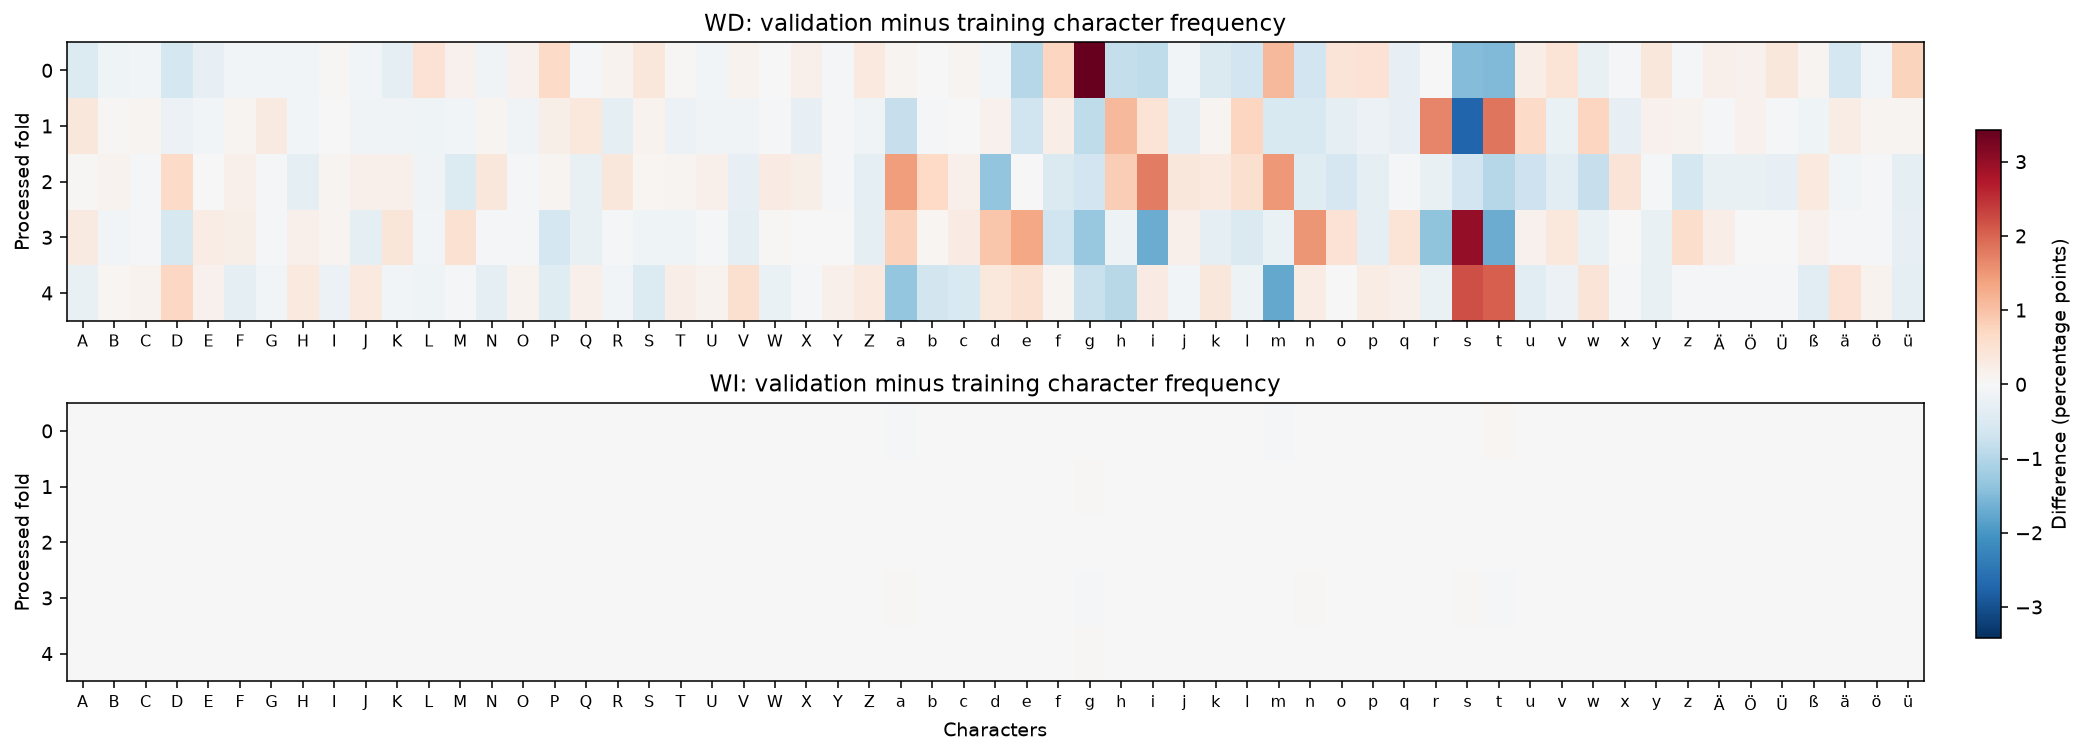

In [5]:
markdown_table(
    ["Setting", "Fold", "TV", "JS (bits)", "Largest gap (pp)",
     "Absent in train", "Absent in validation"],
    [[r["setting"], r["fold"], f'{r["total_variation"]:.6f}',
      f'{r["js_divergence_bits"]:.6f}', f'{r["max_gap_pp"]:.3f}',
      " ".join(r["absent_train"]) or "None",
      " ".join(r["absent_val"]) or "None"] for r in summary_rows],
)

fig, axes = plt.subplots(2, 1, figsize=(15, 5.5), sharex=True)
deltas = {
    setting: np.array([
        (distributions[setting, fold]["val"]["frequency"]
         - distributions[setting, fold]["train"]["frequency"]) * 100
        for fold in FOLDS[setting]
    ])
    for setting in ("WD", "WI")
}
limit = max(float(np.abs(values).max()) for values in deltas.values()) or 1.0
for ax, setting in zip(axes, ("WD", "WI")):
    image = ax.imshow(deltas[setting], cmap="RdBu_r",
                      vmin=-limit, vmax=limit, aspect="auto")
    ax.set_title(f"{setting}: validation minus training character frequency")
    ax.set_yticks(range(len(FOLDS[setting])), FOLDS[setting])
    ax.set_ylabel("Processed fold")
    ax.set_xticks(range(len(ALPHABET)), ALPHABET, fontsize=8)
    ax.tick_params(axis="x", labelbottom=True)
axes[-1].set_xlabel("Characters")
fig.tight_layout(rect=(0, 0, 0.93, 1))
colorbar_ax = fig.add_axes((0.945, 0.16, 0.012, 0.66))
fig.colorbar(image, cax=colorbar_ax, label="Difference (percentage points)")
figures["character_distribution_all_folds_differences"] = fig
plt.show()

## Check the paper's stated observations

Appendix A says WI training/validation frequencies almost match and every character is represented in both sets. For WD, it specifically says `q` and `ä` are absent from validation. The tables below check those statements against our chosen fold. A mismatch may reflect a different dataset version, filtering, or fold assignment; it is not proof of an implementation error.

In [6]:
selected = [r for r in summary_rows if r["fold"] == FOLD_TO_PLOT]
observations = []
for row in selected:
    setting = row["setting"]
    dist = distributions[setting, FOLD_TO_PLOT]
    train_present = not row["absent_train"]
    val_present = not row["absent_val"]
    observations.append([
        setting, f'{row["total_variation"]:.6f}',
        "Yes" if train_present else "No",
        "Yes" if val_present else "No",
    ])
markdown_table(
    ["Setting", "TV", "Every character in train?", "Every character in validation?"],
    observations,
)
markdown_table(
    ["Setting", "Character", "Train count", "Val count", "Train (%)", "Val (%)"],
    [[r["setting"], r["character"], r["train_count"], r["val_count"],
      f'{100 * r["train_frequency"]:.4f}', f'{100 * r["val_frequency"]:.4f}']
     for r in character_rows
     if r["fold"] == FOLD_TO_PLOT and r["character"] in ("q", "ä", "e")],
)
for setting in ("WD", "WI"):
    rows = sorted(
        (r for r in character_rows
         if r["setting"] == setting and r["fold"] == FOLD_TO_PLOT),
        key=lambda r: abs(r["val_minus_train_pp"]), reverse=True,
    )[:8]
    display(Markdown(f"**{setting}: eight largest character-frequency differences**"))
    markdown_table(
        ["Character", "Train (%)", "Val (%)", "Val − train (pp)"],
        [[r["character"], f'{100 * r["train_frequency"]:.3f}',
          f'{100 * r["val_frequency"]:.3f}', f'{r["val_minus_train_pp"]:+.3f}']
         for r in rows],
    )

display(Markdown(
    "**Interpretation:** compare our fold-0 bars visually with the paper's Figure 3, "
    "then inspect the tables for the stated missing characters and split balance. "
    "Inspect the other folds if the missing-character pattern differs: the preparation "
    "notebook does not preserve an explicit raw-to-processed fold mapping. "
    "Similar plots leave writer-specific recognition difficulty unresolved. "
    "A numerical paper-to-public comparison needs the authors' per-character counts "
    "and an agreed fold mapping; do not treat values estimated from the screenshot "
    "as exact counts."
))

summary_by_setting = {row["setting"]: row for row in selected}
wi = summary_by_setting["WI"]
wd = summary_by_setting["WD"]
wd_missing = ", ".join(wd["absent_val"]) or "none"
display(Markdown(
    f"**Our processed fold {FOLD_TO_PLOT}:** WD validation is missing "
    f"{wd_missing}. WI's largest train–validation frequency gap is "
    f"{wi['max_gap_pp']:.4f} percentage points, with "
    f"{len(wi['absent_train'])} missing training characters and "
    f"{len(wi['absent_val'])} missing validation characters. "
    "For fold 0, this reproduces the paper's specific observations about "
    "q/ä absence in WD and balanced character coverage in WI. "
    "The chart resemblance is visual evidence of similar label distributions, "
    "not evidence that the sensor recordings are identical or that the published "
    "recognition scores must reproduce."
) if FOLD_TO_PLOT == 0 else Markdown(
    f"**Processed fold {FOLD_TO_PLOT}:** inspect the results above; the paper's "
    "Figure 3 only supplies the first-fold reference."
))


| Setting | TV | Every character in train? | Every character in validation? |
| --- | --- | --- | --- |
| WD | 0.117020 | Yes | No |
| WI | 0.002293 | Yes | Yes |

| Setting | Character | Train count | Val count | Train (%) | Val (%) |
| --- | --- | --- | --- | --- | --- |
| WD | e | 17735 | 4383 | 16.3382 | 15.3644 |
| WD | q | 299 | 0 | 0.2755 | 0.0000 |
| WD | ä | 649 | 0 | 0.5979 | 0.0000 |
| WI | e | 17462 | 4656 | 16.1388 | 16.1236 |
| WI | q | 237 | 62 | 0.2190 | 0.2147 |
| WI | ä | 511 | 138 | 0.4723 | 0.4779 |

**WD: eight largest character-frequency differences**

| Character | Train (%) | Val (%) | Val − train (pp) |
| --- | --- | --- | --- |
| g | 2.217 | 5.640 | +3.424 |
| t | 6.077 | 4.564 | -1.513 |
| s | 5.366 | 3.874 | -1.493 |
| m | 2.240 | 3.358 | +1.119 |
| e | 16.338 | 15.364 | -0.974 |
| i | 7.565 | 6.699 | -0.866 |
| h | 4.172 | 3.355 | -0.818 |
| ü | 0.287 | 1.055 | +0.769 |

**WI: eight largest character-frequency differences**

| Character | Train (%) | Val (%) | Val − train (pp) |
| --- | --- | --- | --- |
| t | 5.751 | 5.807 | +0.057 |
| a | 5.714 | 5.669 | -0.046 |
| m | 2.479 | 2.448 | -0.030 |
| r | 7.099 | 7.123 | +0.024 |
| w | 1.428 | 1.451 | +0.023 |
| s | 5.059 | 5.042 | -0.017 |
| e | 16.139 | 16.124 | -0.015 |
| f | 0.996 | 1.011 | +0.015 |

**Interpretation:** compare our fold-0 bars visually with the paper's Figure 3, then inspect the tables for the stated missing characters and split balance. Inspect the other folds if the missing-character pattern differs: the preparation notebook does not preserve an explicit raw-to-processed fold mapping. Similar plots leave writer-specific recognition difficulty unresolved. A numerical paper-to-public comparison needs the authors' per-character counts and an agreed fold mapping; do not treat values estimated from the screenshot as exact counts.

**Our processed fold 0:** WD validation is missing K, q, ä. WI's largest train–validation frequency gap is 0.0569 percentage points, with 0 missing training characters and 0 missing validation characters. For fold 0, this reproduces the paper's specific observations about q/ä absence in WD and balanced character coverage in WI. The chart resemblance is visual evidence of similar label distributions, not evidence that the sensor recordings are identical or that the published recognition scores must reproduce.

## Export figures, exact counts, and annotation provenance

With `EXPORT=True`, Run All saves PNG/PDF figures, a CSV of per-character counts and frequencies, a CSV of fold summaries, and a JSON report including SHA-256 hashes of the four input annotation files. These hashes identify the annotations only; they do not authenticate sensor CSV contents. No dataset or experiment files are modified.

In [7]:
if EXPORT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for name, fig in figures.items():
        fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
        fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    def export_csv(path, rows):
        with path.open("w", encoding="utf-8", newline="") as handle:
            writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
            writer.writeheader()
            for row in rows:
                writer.writerow({
                    key: json.dumps(value, ensure_ascii=False)
                    if isinstance(value, list) else value
                    for key, value in row.items()
                })
    export_csv(OUTPUT_DIR / "character_counts_all_folds.csv", character_rows)
    export_csv(OUTPUT_DIR / "fold_summary.csv", summary_rows)
    report = {
        "paper_url": PAPER_URL,
        "comparison": "Visual comparison only; no numerical paper counts supplied.",
        "plotted_processed_fold": FOLD_TO_PLOT,
        "alphabet": ALPHABET,
        "counting": "All case-sensitive label character occurrences; normalized within each split.",
        "source_annotations": source_records,
        "fold_summary": summary_rows,
        "software": {"numpy": np.__version__, "matplotlib": plt.matplotlib.__version__},
    }
    (OUTPUT_DIR / "distribution_report.json").write_text(
        json.dumps(report, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
    )
    print("Saved:")
    for path in sorted(OUTPUT_DIR.iterdir()):
        if path.suffix in (".png", ".pdf", ".csv", ".json"):
            print(f"  {path.name}")
else:
    print("Export disabled; figures and tables remain in notebook output.")

Saved:
  character_counts_all_folds.csv
  character_distribution_all_folds_differences.pdf
  character_distribution_all_folds_differences.png
  character_distribution_fold0.pdf
  character_distribution_fold0.png
  distribution_report.json
  fold_summary.csv
